<a href="https://colab.research.google.com/github/MikeTX56/DL-projects/blob/main/Linear_regression_kerasTf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Activation
from tensorflow.keras.datasets import boston_housing
from tensorflow.keras import layers

import tensorflow as tf
import matplotlib.pyplot as plt

In [19]:
np.random.seed(42)
tf.random.set_seed(42)

In [20]:
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

In [21]:
boston_features = {
    "Average Number of Rooms" : 5,
}

In [22]:
X_train_ld = X_train[:,boston_features["Average Number of Rooms"]]

In [35]:
X_test_ld = X_test[:,boston_features["Average Number of Rooms"]]

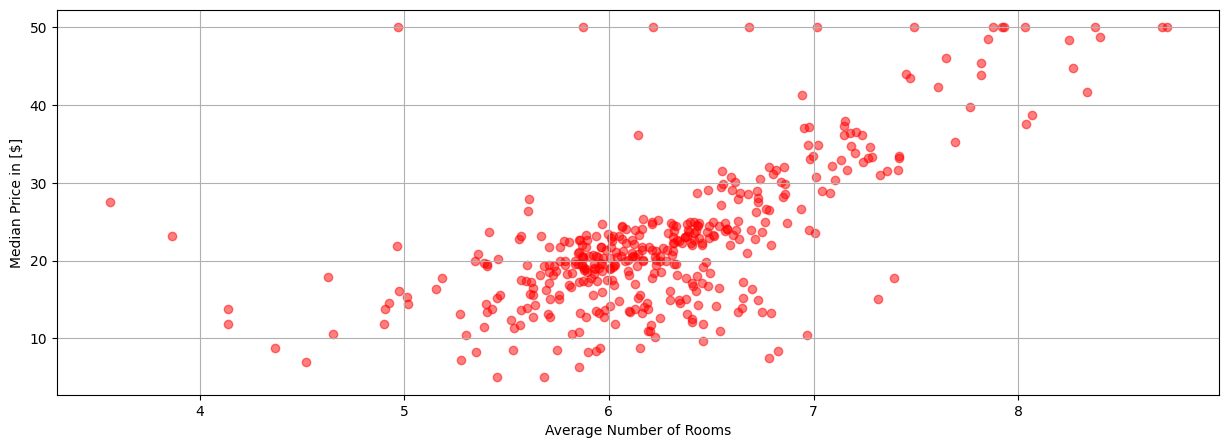

In [23]:
plt.figure(figsize=(15, 5))
plt.xlabel("Average Number of Rooms")
plt.ylabel("Median Price in [$]")
plt.grid(True)
plt.scatter(X_train_ld[:], y_train, color = "red", alpha = 0.5);

In [24]:
model = Sequential()
model.add(Dense(units = 1, input_shape = (1, )))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(optimizer = tf.keras.optimizers.RMSprop(learning_rate = 0.005), loss = "mse")

In [26]:
history = model.fit(X_train_ld,
                    y_train,
                    batch_size = 16,
                    epochs = 101,
                    validation_split = 0.3)

Epoch 1/101
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 271.6829 - val_loss: 356.1202
Epoch 2/101
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 248.4428 - val_loss: 334.6728
Epoch 3/101
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 230.8879 - val_loss: 314.7536
Epoch 4/101
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 214.5296 - val_loss: 295.7693
Epoch 5/101
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 199.0354 - val_loss: 277.6369
Epoch 6/101
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 184.3571 - val_loss: 260.3431
Epoch 7/101
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 170.4854 - val_loss: 243.8847
Epoch 8/101
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 157.4166 - val_loss: 228.2596
Epoch 9/101
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 145.1474 - val_loss: 213.4664
Epoch 10/101
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 133.6741 - val_loss: 199.5029
Epoch 11/101
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 122.9926 - val_loss: 186.3669
Epoch 12/101
18/18

In [27]:
def plot_loss(history):
  plt.figure(figsize = (20,  5))
  plt.plot(history.history["loss"], "g", label = "Training Loss")
  plt.plot(history.history["val_loss"], "b", label = "Validation Loss")
  plt.xlim([0, 100])
  plt.ylim([0, 300])
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()
  plt.grid(True)

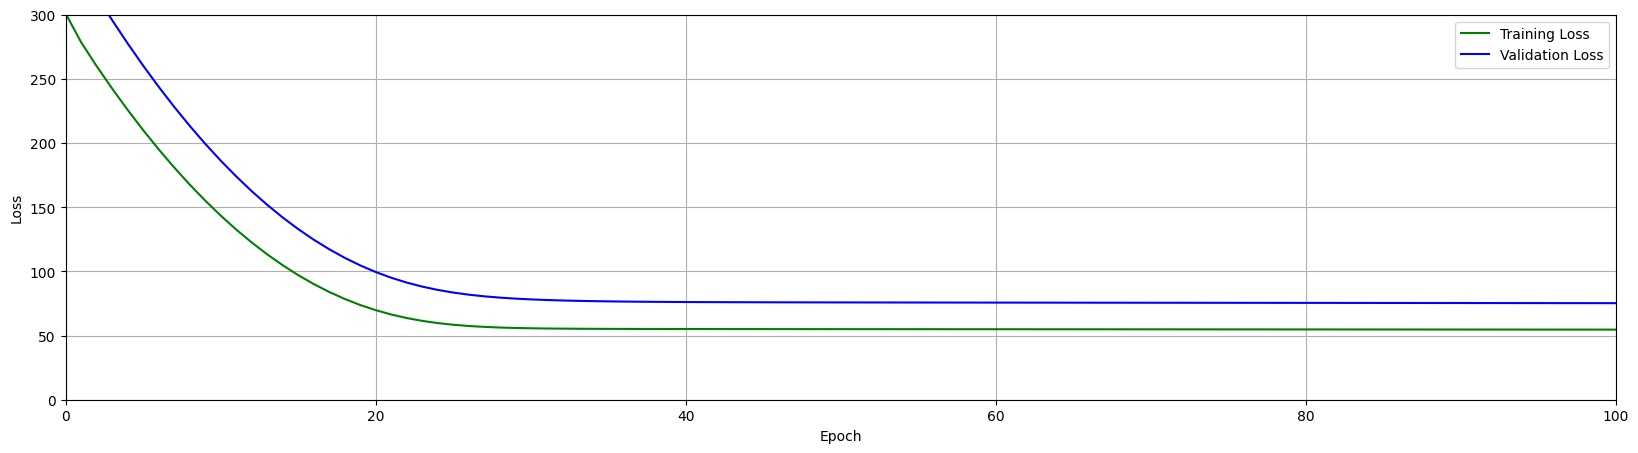

In [28]:
plot_loss(history)

In [29]:
x = [3,4,5,6,7]
x = np.array(x)
x = x.reshape(-1, 1)
y_pred = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


In [30]:
for idx in range(len(x)):
  print("Predicted price of a homw with {} rooms: ${}K".format(x[idx][0], int(y_pred[idx]*10)/10))

Predicted price of a homw with 3 rooms: $11.4K
Predicted price of a homw with 4 rooms: $14.7K
Predicted price of a homw with 5 rooms: $18.0K
Predicted price of a homw with 6 rooms: $21.3K
Predicted price of a homw with 7 rooms: $24.6K


/tmp/ipykernel_263/2841480288.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Predicted price of a homw with {} rooms: ${}K".format(x[idx][0], int(y_pred[idx]*10)/10))


In [31]:
x = tf.linspace(3, 9, 10)
y = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [32]:
def plot_data(x_data, y_data, x, y, title = None):
  plt.figure(figsize = (15, 5))
  plt.scatter(x_data, y_data, label = "Ground Truth", color = "green", alpha = 0.5)
  plt.plot(x, y, color="k", label = "Model Predictions")
  plt.xlim([3, 9])
  plt.ylim([0, 60])
  plt.xlabel('Average Number of Rooms')
  plt.ylabel('Price [$K]')
  plt.title(title)
  plt.grid(True)
  plt.legend()

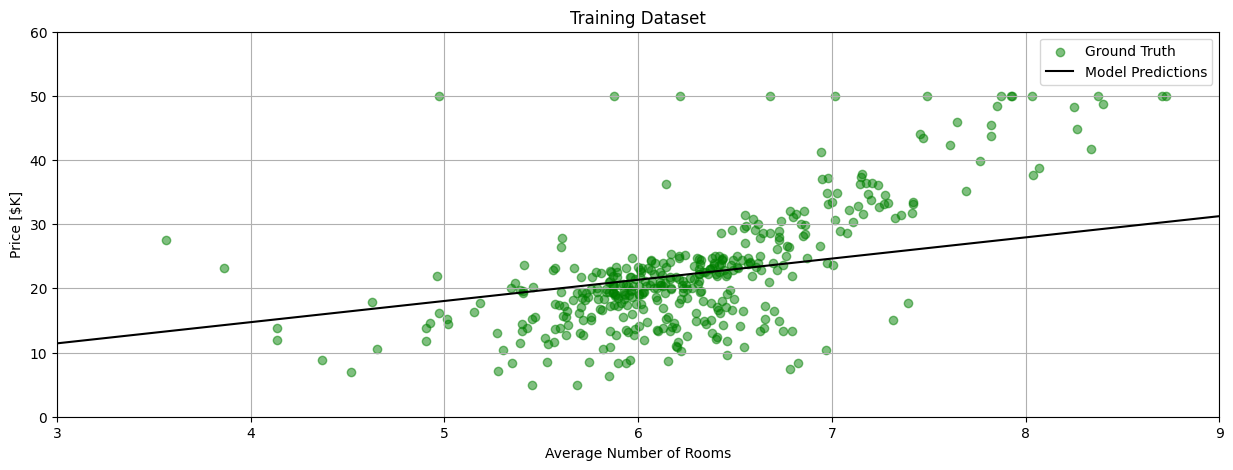

In [33]:
plot_data(X_train_ld, y_train, x , y, title = "Training Dataset")

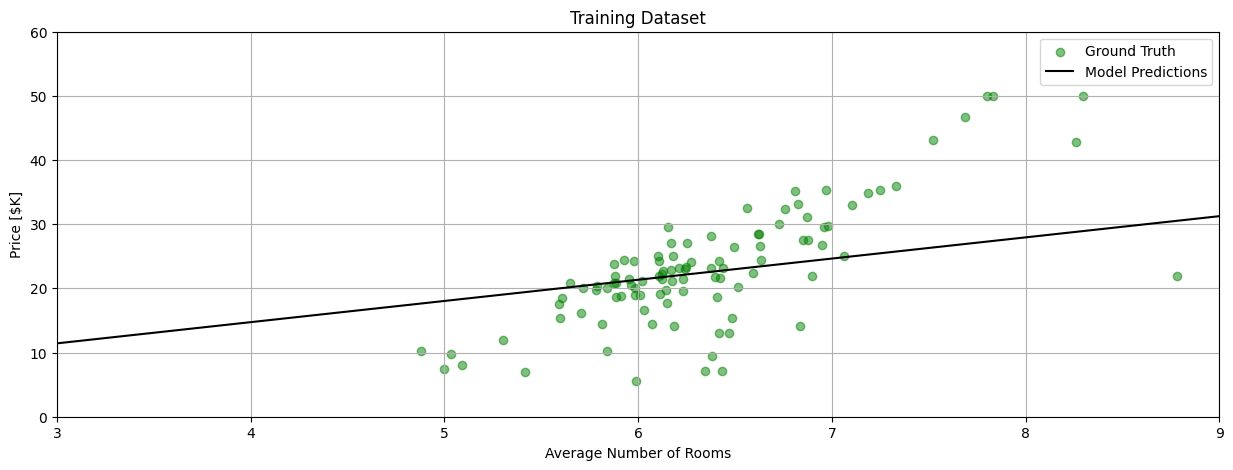

In [37]:
plot_data(X_test_ld, y_test,x, y, title = "Training Dataset")